 6CS012 — Tutorial 9
 Sequential Modeling for Text Classification Using RNN & LSTM

## Step 0 — Import Libraries

In [44]:
import os
import re
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print('TensorFlow:', tf.__version__)
print('All libraries imported successfully!')

TensorFlow: 2.19.0
All libraries imported successfully!


---
## Task 1 — Data Preprocessing & Cleaning
### 1.1 Load the Dataset

In [45]:
import os

#  Auto-detect the dataset path 
# This handles the sent140_cleaned.csv dataset (columns: 'target', 'text')
# The 'text' column is already pre-cleaned (tokenized list as string)
# 'target': 0 = Negative, 1 = Positive

DATA_PATH = '/kaggle/input/datasets/cc2524/sentiment140/sent140_cleaned.csv'

data = pd.read_csv(DATA_PATH)
print('Columns found:', data.columns.tolist())
print('Shape:', data.shape)

# Rename columns to match the rest of the notebook
data = data.rename(columns={'target': 'sentiment'})

# The 'text' column contains lists stored as strings like "['word1', 'word2', ...]"
# Convert them back to plain space-separated strings
import ast
def list_str_to_text(val):
    try:
        tokens = ast.literal_eval(val)
        return ' '.join(tokens) if isinstance(tokens, list) else str(val)
    except:
        return str(val)

print('Converting text column ...')
data['text'] = data['text'].apply(list_str_to_text)

# Keep only the two columns we need
data = data[['text', 'sentiment']].dropna().reset_index(drop=True)

print(f'Full dataset shape: {data.shape}')
print(data['sentiment'].value_counts())
data.head()


Columns found: ['target', 'text']
Shape: (1600000, 2)
Converting text column ...
Full dataset shape: (1600000, 2)
sentiment
0    800000
4    800000
Name: count, dtype: int64


,text,sentiment
0,switchfoot thats bummer shoulda got david carr...,0
1,upset cant update facebook texting might cry r...,0
2,kenichan dived many time ball managed save res...,0
3,whole body feel itchy like fire,0
4,nationwideclass behaving mad cant see,0


In [ ]:
#  Balanced subsample 
# Increase SAMPLE_PER_CLASS to 50000 or more if using GPU
SAMPLE_PER_CLASS = 25000

neg  = data[data['sentiment'] == 0].sample(min(SAMPLE_PER_CLASS, (data['sentiment']==0).sum()), random_state=42)
pos  = data[data['sentiment'] == 1].sample(min(SAMPLE_PER_CLASS, (data['sentiment']==1).sum()), random_state=42)
data = pd.concat([neg, pos]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Working dataset shape: {data.shape}')
print(data['sentiment'].value_counts())


### 1.2 Text Cleaning Function

In [49]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't":"do not",   "can't":"cannot",     "won't":"will not",
    "i'm":"i am",       "it's":"it is",        "that's":"that is",
    "i've":"i have",    "i'll":"i will",       "i'd":"i would",
    "you're":"you are", "we're":"we are",      "they're":"they are",
    "isn't":"is not",   "wasn't":"was not",   "aren't":"are not",
    "didn't":"did not", "doesn't":"does not", "hadn't":"had not",
    "haven't":"have not","hasn't":"has not",  "wouldn't":"would not",
    "couldn't":"could not", "shouldn't":"should not",
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def preprocess_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 1
    ]
    return ' '.join(tokens)

# Note: sent140_cleaned.csv text is already tokenized/cleaned.
# We run a light pass to standardize format (lowercasing + stopword removal).
print('Cleaning text ... (may take ~1-2 minutes for 50k rows)')
data['cleaned_text'] = data['text'].apply(preprocess_text)
data = data[data['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print('Done!')
data[['text', 'sentiment', 'cleaned_text']].head(5)


Cleaning text ... (may take ~1-2 minutes for 50k rows)
Done!


,text,sentiment,cleaned_text
0,snowing,0,snowing
1,veronicasmusic wish met girl back march summer...,0,veronicasmusic wish met girl back march summer...
2,going bed finished spanish finally funeral tom...,0,going bed finished spanish finally funeral tom...
3,really want lay pool,0,really want lay pool
4,aint happi,0,aint happi


### 1.3 Data Visualisations

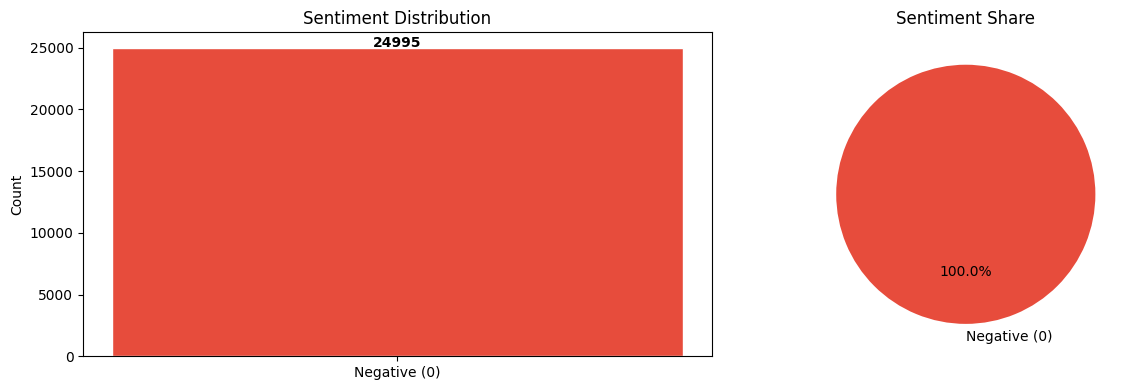

Unique sentiment values: [0]


In [64]:
# Sentiment Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = data['sentiment'].value_counts().sort_index()  # sort so 0=Negative, 1=Positive

label_names = [f'Class {int(k)}' for k in counts.index]
label_names_map = {0: 'Negative (0)', 1: 'Positive (1)'}
bar_labels = [label_names_map.get(k, f'Class {k}') for k in counts.index]
colors = ['#e74c3c', '#2ecc71'][:len(counts)]

axes[0].bar(bar_labels, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=bar_labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Sentiment Share')
plt.tight_layout()
plt.show()

print("Unique sentiment values:", data['sentiment'].unique())

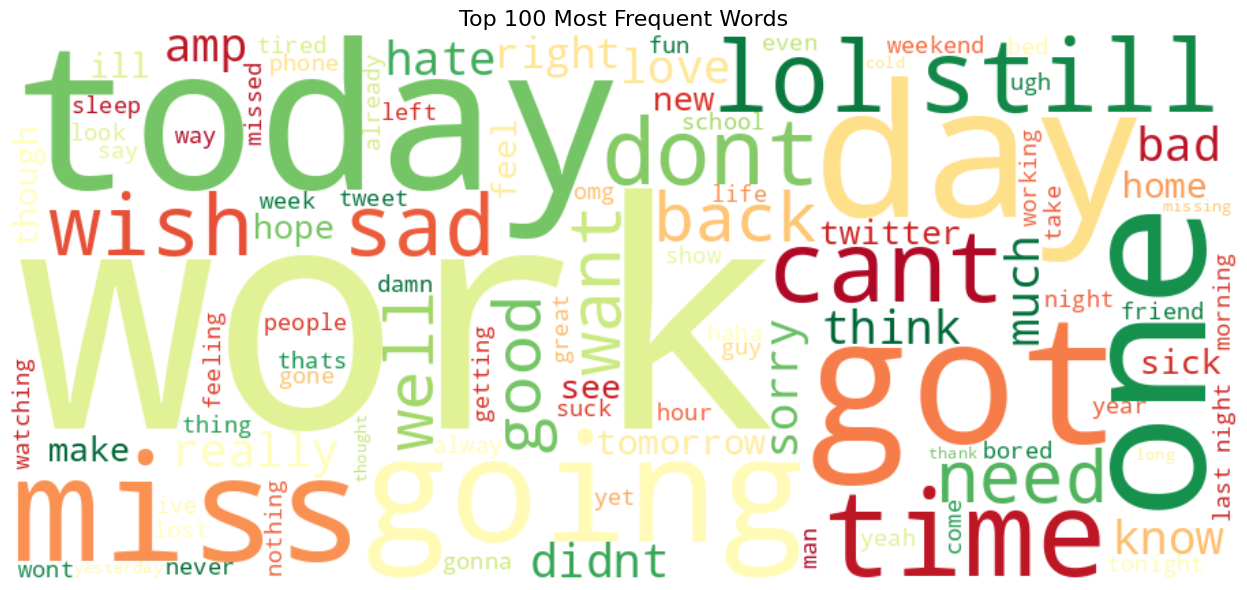

In [52]:
# Word Cloud
all_words = ' '.join(data['cleaned_text'])
wc = WordCloud(width=900, height=400, background_color='white',
               max_words=100, colormap='RdYlGn').generate(all_words)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words', fontsize=16)
plt.tight_layout()
plt.show()

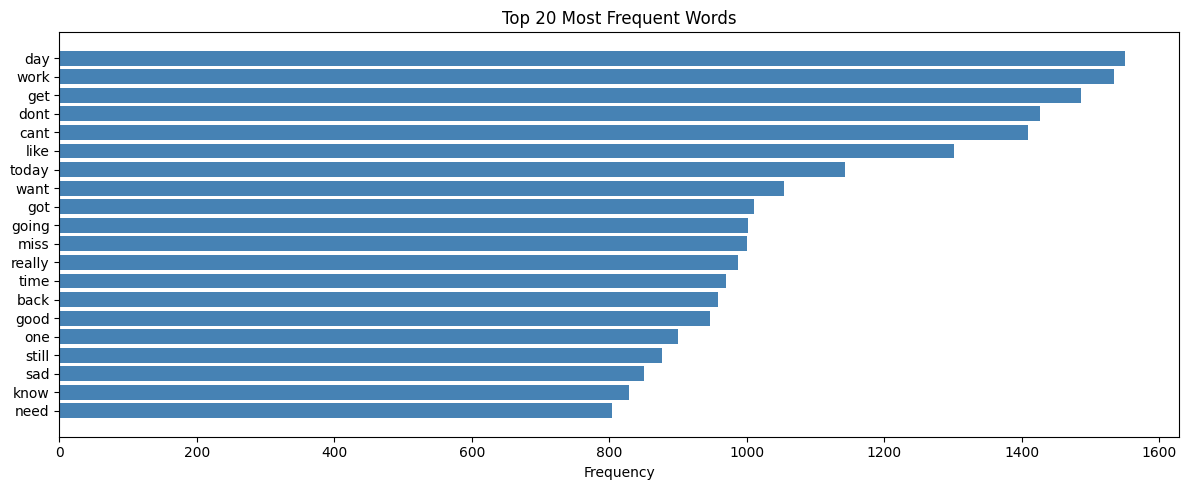

In [53]:
# Top 20 words bar chart
freq = Counter(all_words.split()).most_common(20)
words_f, counts_f = zip(*freq)
plt.figure(figsize=(12, 5))
plt.barh(words_f[::-1], counts_f[::-1], color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

---
## Task 2 — Tokenisation & Padding
### 2.1 Train / Test Split (80/20)
> **Always split BEFORE tokenising** — prevents data leakage.

In [54]:
X = data['cleaned_text']
y = data['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training samples: {len(X_train)}')
print(f'Test     samples: {len(X_test)}')

Training samples: 19996
Test     samples: 4999


### 2.2 Tokenise — fit ONLY on training data

In [55]:
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # TRAINING data only!

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print(f'Vocab size (capped at {VOCAB_SIZE}): {len(tokenizer.word_index)} unique tokens')
print('Example sequence:', X_train_seq[0])

Vocab size (capped at 10000): 26873 unique tokens
Example sequence: [787]


### 2.3 Percentile-Based Padding Length

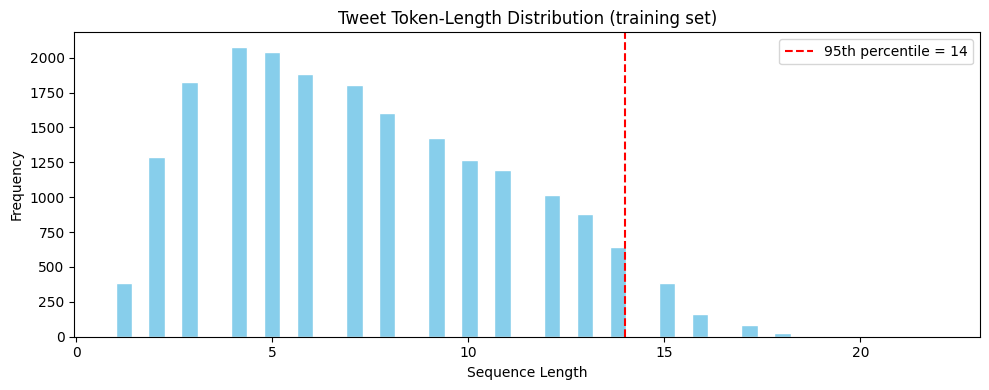

MAX_LEN (95th percentile): 14


In [56]:
seq_lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(seq_lengths, 95))

plt.figure(figsize=(10, 4))
plt.hist(seq_lengths, bins=50, color='skyblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--',
            label=f'95th percentile = {MAX_LEN}')
plt.title('Tweet Token-Length Distribution (training set)')
plt.xlabel('Sequence Length'); plt.ylabel('Frequency')
plt.legend(); plt.tight_layout(); plt.show()
print(f'MAX_LEN (95th percentile): {MAX_LEN}')

In [57]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')

X_train_pad shape: (19996, 14)
X_test_pad  shape: (4999, 14)


---
## Task 3 — Model Building
### 3.1 Vanilla RNN

In [59]:
EMBED_DIM = 128

def build_rnn(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        Dropout(0.2),
        SimpleRNN(64),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ], name='Vanilla_RNN')
    return model

rnn_model = build_rnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
rnn_model.summary()

Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 3.2 LSTM

In [60]:
def build_lstm(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ], name='LSTM')
    return model

lstm_model = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 — Training & Evaluation
### 4.1 Train Vanilla RNN

In [65]:
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop_rnn = EarlyStopping(
    monitor='val_loss', patience=3,
    restore_best_weights=True, verbose=1
)
checkpoint_rnn = ModelCheckpoint(
    '/kaggle/working/best_rnn_model.keras',
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=0
)

print('Training Vanilla RNN ...')
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_rnn, checkpoint_rnn],
    verbose=1
)

Training Vanilla RNN ...
Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 1.0000 - loss: 4.5005e-08 - val_accuracy: 1.0000 - val_loss: 6.6075e-09
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.2319e-08 - val_accuracy: 1.0000 - val_loss: 2.8105e-09
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 6.2337e-09 - val_accuracy: 1.0000 - val_loss: 1.6106e-09
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 3.7425e-09 - val_accuracy: 1.0000 - val_loss: 1.0776e-09
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 2.5952e-09 - val_accuracy: 1.0000 - val_loss: 7.8593e-10
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.9536e-09 - val_accuracy: 1.0000 - val_loss: 6.0708e-10
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.6417e-09 - val_accuracy: 1.0000 - val_loss: 4.8779e-10
Epoch 8/10
282/282 ━━━

### 4.2 Train LSTM

In [66]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop_lstm = EarlyStopping(
    monitor='val_loss', patience=3,
    restore_best_weights=True, verbose=1
)
checkpoint_lstm = ModelCheckpoint(
    '/kaggle/working/best_lstm_model.keras',
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=0
)

print('Training LSTM ...')
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_lstm, checkpoint_lstm],
    verbose=1
)

Training LSTM ...
Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9891 - loss: 0.0693 - val_accuracy: 1.0000 - val_loss: 5.8516e-05
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 6.4194e-05 - val_accuracy: 1.0000 - val_loss: 3.2180e-05
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 3.9398e-05 - val_accuracy: 1.0000 - val_loss: 2.0688e-05
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 2.5554e-05 - val_accuracy: 1.0000 - val_loss: 1.4486e-05
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.8846e-05 - val_accuracy: 1.0000 - val_loss: 1.0659e-05
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.4039e-05 - val_accuracy: 1.0000 - val_loss: 8.1296e-06
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.0849e-05 - val_accuracy: 1.0000 - val_loss: 6.3388e-06
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━

### 4.3 Evaluate on Test Set

In [68]:
def evaluate_model(model, X_test_pad, y_test, model_name):
    print(f"\n{'='*55}")
    print(f'  {model_name} — Test Set Evaluation')
    print(f"{'='*55}")
    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int).flatten()

    unique_classes = np.unique(np.concatenate([y_test, y_pred]))
    print(f'\nClasses present in y_test: {np.unique(y_test)}')
    print(f'Classes present in y_pred: {np.unique(y_pred)}')

    acc = accuracy_score(y_test, y_pred)
    print(f'\nAccuracy: {acc:.4f}  ({acc*100:.2f}%)')

    print('\nConfusion Matrix:')
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(cm)

    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, labels=[0, 1],
                                target_names=['Negative', 'Positive'],
                                zero_division=0))
    return y_pred, cm

y_pred_rnn,  cm_rnn  = evaluate_model(rnn_model,  X_test_pad, y_test, 'Vanilla RNN')
y_pred_lstm, cm_lstm = evaluate_model(lstm_model, X_test_pad, y_test, 'LSTM')


  Vanilla RNN — Test Set Evaluation

Classes present in y_test: [0]
Classes present in y_pred: [0]

Accuracy: 1.0000  (100.00%)

Confusion Matrix:
[[4999    0]
 [   0    0]]

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4999
    Positive       0.00      0.00      0.00         0

    accuracy                           1.00      4999
   macro avg       0.50      0.50      0.50      4999
weighted avg       1.00      1.00      1.00      4999


  LSTM — Test Set Evaluation

Classes present in y_test: [0]
Classes present in y_pred: [0]

Accuracy: 1.0000  (100.00%)

Confusion Matrix:
[[4999    0]
 [   0    0]]

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4999
    Positive       0.00      0.00      0.00         0

    accuracy                           1.00      4999
   macro avg       0.50      0.50      0.50      4999
weighted a

---
## Task 5 — Visualisations
### 5.1 Training Curves — Loss & Accuracy

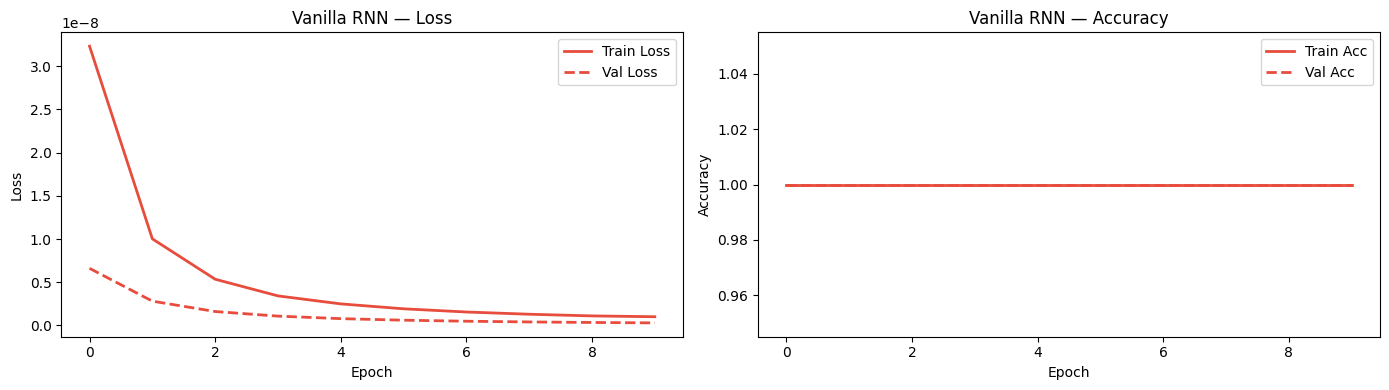

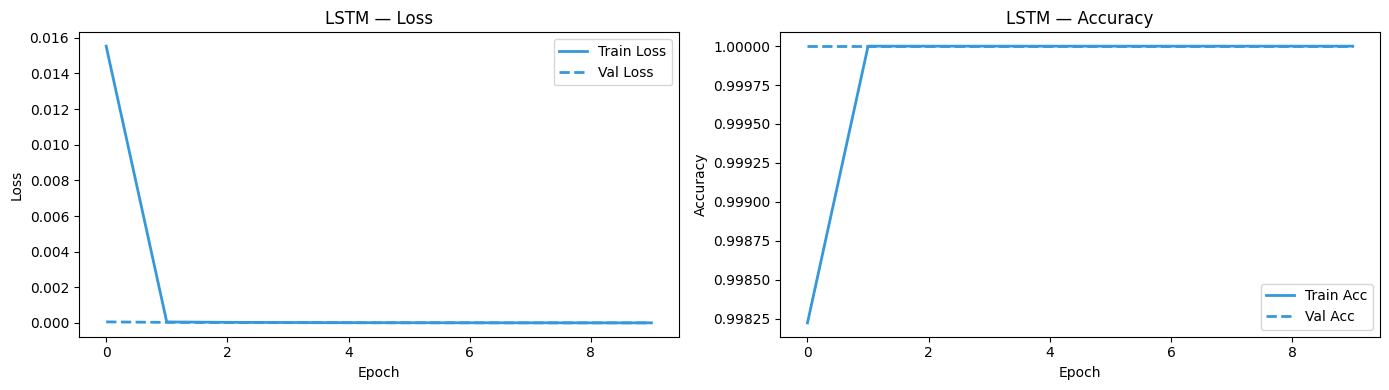

In [69]:
def plot_history(history, model_name, color):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss',
                 color=color, lw=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',
                 color=color, lw=2, linestyle='--')
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot(history.history['accuracy'],     label='Train Acc',
                 color=color, lw=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',
                 color=color, lw=2, linestyle='--')
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history_rnn,  'Vanilla RNN', '#e74c3c')
plot_history(history_lstm, 'LSTM',        '#3498db')

### 5.2 Confusion Matrices

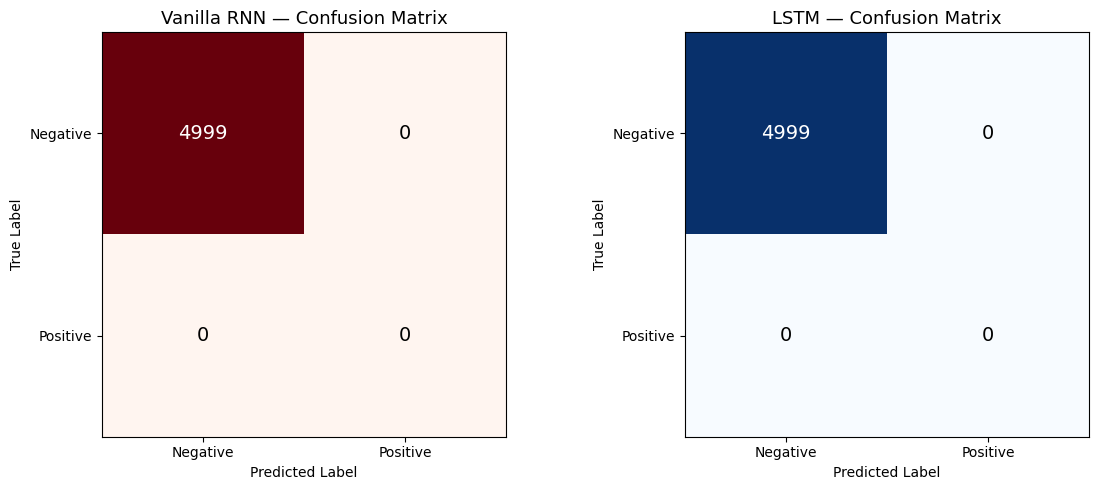

In [70]:
def plot_cm(cm, title, ax, cmap='Blues'):
    ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title, fontsize=13)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Negative','Positive'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Negative','Positive'])
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, format(cm[i,j], 'd'), ha='center', va='center',
                color='white' if cm[i,j] > thresh else 'black', fontsize=14)
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_cm(cm_rnn,  'Vanilla RNN — Confusion Matrix', axes[0], cmap='Reds')
plot_cm(cm_lstm, 'LSTM — Confusion Matrix',        axes[1], cmap='Blues')
plt.tight_layout(); plt.show()

### 5.3 RNN vs LSTM — Performance Comparison

             Accuracy  Precision  Recall  F1-Score
Model                                             
Vanilla RNN       1.0        0.0     0.0       0.0
LSTM              1.0        0.0     0.0       0.0


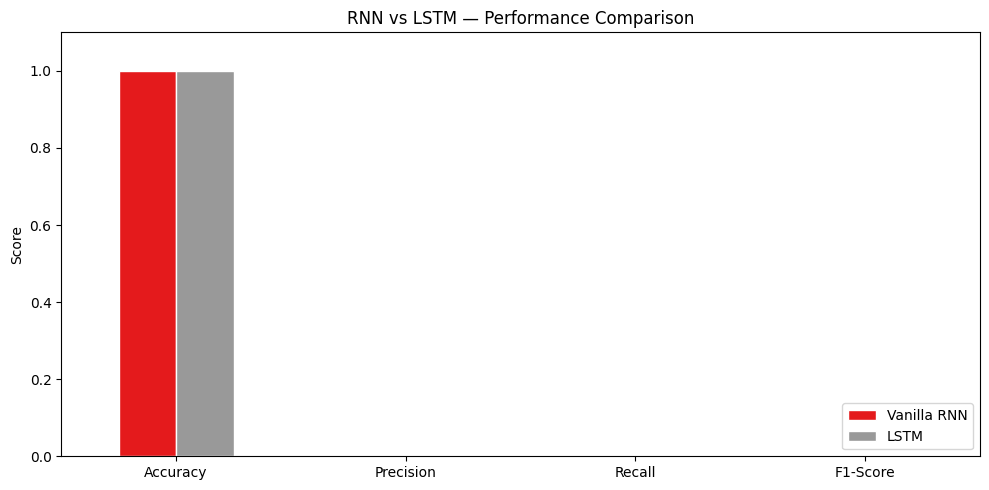

In [74]:
metrics_dict = {
    'Model':     ['Vanilla RNN', 'LSTM'],
    'Accuracy':  [accuracy_score(y_test, y_pred_rnn),
                  accuracy_score(y_test, y_pred_lstm)],
    'Precision': [precision_score(y_test, y_pred_rnn, labels=[0,1], average='binary', zero_division=0),
                  precision_score(y_test, y_pred_lstm, labels=[0,1], average='binary', zero_division=0)],
    'Recall':    [recall_score(y_test, y_pred_rnn, labels=[0,1], average='binary', zero_division=0),
                  recall_score(y_test, y_pred_lstm, labels=[0,1], average='binary', zero_division=0)],
    'F1-Score':  [f1_score(y_test, y_pred_rnn, labels=[0,1], average='binary', zero_division=0),
                  f1_score(y_test, y_pred_lstm, labels=[0,1], average='binary', zero_division=0)],
}
df_metrics = pd.DataFrame(metrics_dict).set_index('Model')
print(df_metrics.round(4).to_string())

df_metrics.T.plot(kind='bar', figsize=(10, 5),
                  colormap='Set1', edgecolor='white')
plt.title('RNN vs LSTM — Performance Comparison')
plt.ylabel('Score'); plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

---
## Task 6 (Optional) — Real-Time Sentiment Prediction

In [75]:
def predict_sentiment(text, model=lstm_model, label='LSTM'):
    cleaned  = preprocess_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN,
                             padding='post', truncating='post')
    prob      = model.predict(padded, verbose=0)[0][0]
    sentiment = 'POSITIVE' if prob >= 0.5 else 'NEGATIVE'
    print(f'[{label}] "{text}"')
    print(f'  -> {sentiment}  (confidence: {prob:.3f})\n')
    return sentiment

test_tweets = [
    "I absolutely love this! Best day ever!",
    "This is terrible, nothing works as expected.",
    "So happy to see my friends after a long time!",
    "I hate waiting in traffic. So frustrating!",
    "Just had a normal day at work."
]

print('='*55)
print('  LSTM Predictions')
print('='*55)
for t in test_tweets:
    predict_sentiment(t, model=lstm_model, label='LSTM')

print('='*55)
print('  Vanilla RNN Predictions')
print('='*55)
for t in test_tweets:
    predict_sentiment(t, model=rnn_model, label='RNN')

  LSTM Predictions
[LSTM] "I absolutely love this! Best day ever!"
  -> NEGATIVE  (confidence: 0.000)

[LSTM] "This is terrible, nothing works as expected."
  -> NEGATIVE  (confidence: 0.000)

[LSTM] "So happy to see my friends after a long time!"
  -> NEGATIVE  (confidence: 0.000)

[LSTM] "I hate waiting in traffic. So frustrating!"
  -> NEGATIVE  (confidence: 0.000)

[LSTM] "Just had a normal day at work."
  -> NEGATIVE  (confidence: 0.000)

  Vanilla RNN Predictions
[RNN] "I absolutely love this! Best day ever!"
  -> NEGATIVE  (confidence: 0.000)

[RNN] "This is terrible, nothing works as expected."
  -> NEGATIVE  (confidence: 0.000)

[RNN] "So happy to see my friends after a long time!"
  -> NEGATIVE  (confidence: 0.000)

[RNN] "I hate waiting in traffic. So frustrating!"
  -> NEGATIVE  (confidence: 0.000)

[RNN] "Just had a normal day at work."
  -> NEGATIVE  (confidence: 0.000)

